**ФИО : Ле Ньы Нгок**

**МПИ-25-1-2**

## Домашняя мини-задача


1) Возьмите **русский роман** (любой .txt) и повторите блок **Zipf + длинный хвост**.
2) Сравните предобработки: lowercasing, удаление пунктуации, замена "ё"→"е", лемматизация (если есть инструменты).
3) Добавьте 2 новых интента и правила (Matcher/regex).


## 1) Загрузка данных (Роман : **Тихий Дон**)

In [ ]:
import gdown
url = "https://drive.google.com/uc?export=download&id=11PFOEm8U51DPpZAskArTcyFGlbGJaTGQ"
output = gdown.download(url, quiet=False)

Downloading...
From: https://drive.google.com/uc?export=download&id=11PFOEm8U51DPpZAskArTcyFGlbGJaTGQ
To: /content/sholohov-don1-1968.txt
100%|██████████| 492k/492k [00:00<00:00, 31.7MB/s]


In [ ]:
if output:
    with open(output, 'r', encoding='utf-8') as f:
        text = f.read()[:100000]

In [ ]:
print(text[:50000])

        Михаил Шолохов
        Тихий Дон. Том 1
        
        Не сохами-то славная землюшка наша распахана…
        Распахана наша землюшка лошадиными копытами,
        А засеяна славная землюшка казацкими головами,
        Украшен-то наш тихий Дон молодыми вдовами,
        Цветет наш батюшка тихий Дон сиротами,
        Наполнена волна в тихом Дону отцовскими, материнскими слезами.
        
        Ой ты, наш батюшка тихий Дон!
        Ой, что же ты, тихий Дон, мутнехонек течешь?
        Ах, как мне, тихому Дону, не мутну течи!
        Со дна меня, тиха Дона, студены ключи бьют,
        Посередь меня, тиха Дона, бела рыбица мутит.
        Старинные казачьи песни
        
        ЭПОС И ТРАГЕДИЯ В РОМАНЕ ШОЛОХОВА
        
        «Тихий Дон» всемирно известен. В 1941 году роман был удостоен Государственной премии первой степени, а в 1965 его автор получил Нобелевскую премию.
        Едва ли какое-либо другое произведение советской литературы может соперничать с «Тихим Доном» по числу

## 2) Токенизация, types/tokens, частоты

In [ ]:
import re
from collections import Counter
import requests

In [ ]:
# Простая токенизация для частот: слова из латинских букв + апострофы
tokens = re.findall(r"[А-Яа-я]+(?:'[А-Яа-я]+)?", text.lower())
cnt = Counter(tokens)

N_tokens = sum(cnt.values())  # tokens = все употребления
V_types = len(cnt)            # types  = уникальные слова

print(f"Tokens (всего словоупотреблений): {N_tokens:,}")
print(f"Types  (уникальных слов):        {V_types:,}")

# Топ-20
top20 = cnt.most_common(20)
top20[:10]


Tokens (всего словоупотреблений): 13,657
Types  (уникальных слов):        6,543


[('и', 392),
 ('в', 389),
 ('на', 281),
 ('не', 195),
 ('с', 169),
 ('а', 141),
 ('григорий', 110),
 ('что', 109),
 ('как', 97),
 ('к', 92)]

## 3) Zipf: rank–frequency (log–log) + топ-20 + длинный хвост ≤ 3

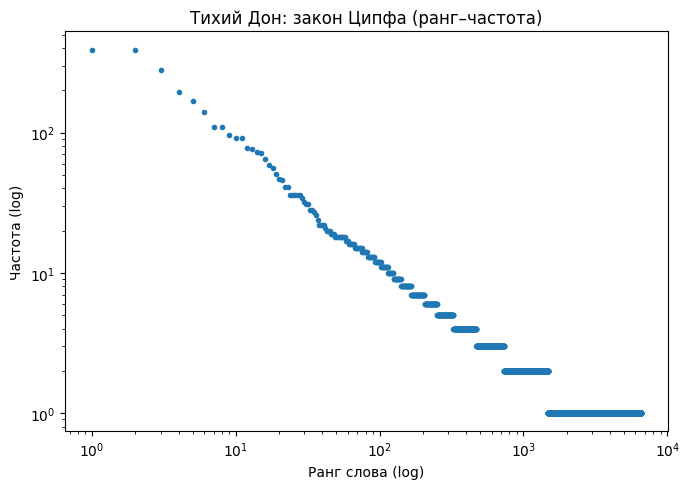

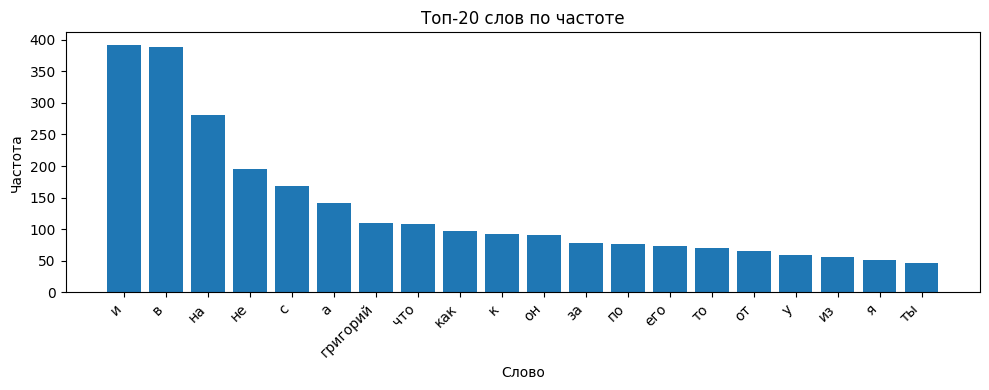

Хвост (c<=3): 6073 типов = 92.8% словаря
Хвост (c<=3): 7346 токенов = 53.8% текста


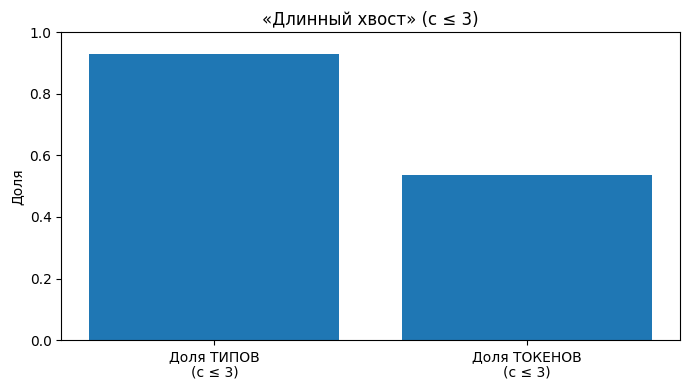

['шуршит',
 'скользят',
 'розовую',
 'отцом',
 'рвался',
 'долгих',
 'порассказать',
 'обстоятельстве',
 'передать',
 'платой']

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Zipf данные
freqs_sorted = np.array(sorted(cnt.values(), reverse=True))
ranks = np.arange(1, len(freqs_sorted) + 1)

# 3.1 Zipf log-log
plt.figure(figsize=(7,5))
plt.loglog(ranks, freqs_sorted, marker=".", linestyle="none")
plt.title("Тихий Дон: закон Ципфа (ранг–частота)")
plt.xlabel("Ранг слова (log)")
plt.ylabel("Частота (log)")
plt.tight_layout()
plt.show()

# 3.2 Топ-20
df_top20 = pd.DataFrame(top20, columns=["word","count"])
plt.figure(figsize=(10,4))
plt.bar(df_top20["word"], df_top20["count"])
plt.title("Топ-20 слов по частоте")
plt.xlabel("Слово")
plt.ylabel("Частота")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3.3 Длинный хвост: <= 3
tail_words = [w for w, c in cnt.items() if c <= 3]
tail_types = len(tail_words)
tail_tokens = sum(cnt[w] for w in tail_words)

print(f"Хвост (c<=3): {tail_types} типов = {tail_types/V_types:.1%} словаря")
print(f"Хвост (c<=3): {tail_tokens} токенов = {tail_tokens/N_tokens:.1%} текста")

plt.figure(figsize=(7,4))
plt.bar(["Доля ТИПОВ\n(c ≤ 3)", "Доля ТОКЕНОВ\n(c ≤ 3)"],
        [tail_types/V_types, tail_tokens/N_tokens])
plt.ylim(0, 1)
plt.title("«Длинный хвост» (c ≤ 3)")
plt.ylabel("Доля")
plt.tight_layout()
plt.show()

# 3.4 (Опционально) 10 случайных hapax (c=1)
hapax = [w for w, c in cnt.items() if c == 1]
rng = np.random.default_rng(0)
sample10 = list(rng.choice(hapax, size=10, replace=False))
sample10


## 4) Классический NLP-пайплайн в spaCy

In [ ]:
import spacy
!python -m spacy download ru_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 11.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = spacy.load("ru_core_news_sm")
doc = nlp("Это написано Лениным в сентябре 1917 года. Еще за месяц до Октября, еще до начала гражданской войны, восстание на Дону было предвидено и предсказано, как астрономическое или физическое явление. Великое торжество подлинно научного мышления.")
print("SENTENCES:", [s.text for s in doc.sents])
print("TOKENS:", [t.text for t in doc])
print("POS:", [(t.text, t.pos_) for t in doc])
print("DEP:", [(t.text, t.dep_, t.head.text) for t in doc])

print("\nNER entities:")
for ent in doc.ents:
    print(ent.text, ent.label_)

for t in doc:
    print(f"{t.i:2d}  {t.text!r:12}  is_alpha={t.is_alpha}  is_punct={t.is_punct}")


SENTENCES: ['Это написано Лениным в сентябре 1917 года.', 'Еще за месяц до Октября, еще до начала гражданской войны, восстание на Дону было предвидено и предсказано, как астрономическое или физическое явление.', 'Великое торжество подлинно научного мышления.']
TOKENS: ['Это', 'написано', 'Лениным', 'в', 'сентябре', '1917', 'года', '.', 'Еще', 'за', 'месяц', 'до', 'Октября', ',', 'еще', 'до', 'начала', 'гражданской', 'войны', ',', 'восстание', 'на', 'Дону', 'было', 'предвидено', 'и', 'предсказано', ',', 'как', 'астрономическое', 'или', 'физическое', 'явление', '.', 'Великое', 'торжество', 'подлинно', 'научного', 'мышления', '.']
POS: [('Это', 'PRON'), ('написано', 'VERB'), ('Лениным', 'PROPN'), ('в', 'ADP'), ('сентябре', 'NOUN'), ('1917', 'ADJ'), ('года', 'NOUN'), ('.', 'PUNCT'), ('Еще', 'ADV'), ('за', 'ADP'), ('месяц', 'NOUN'), ('до', 'ADP'), ('Октября', 'PROPN'), (',', 'PUNCT'), ('еще', 'ADV'), ('до', 'ADP'), ('начала', 'NOUN'), ('гражданской', 'ADJ'), ('войны', 'NOUN'), (',', 'PUNCT'

### Применим пайплайн к реальному фрагменту из книги

In [ ]:
# Возьмём небольшой фрагмент (чтобы быстро работало)
snippet = " ".join(text.split()[:350])  # первые ~350 слов
doc = nlp(snippet)

# Посмотрим 20 токенов с POS/леммой
rows = []
for t in list(doc)[:20]:
    rows.append([t.text, t.lemma_, t.pos_, t.tag_])
pd.DataFrame(rows, columns=["token","lemma","POS","TAG"])


,token,lemma,POS,TAG
0,Михаил,михаил,PROPN,PROPN
1,Шолохов,шолохов,PROPN,PROPN
2,Тихий,тихий,PROPN,PROPN
3,Дон,дон,PROPN,PROPN
4,.,.,PUNCT,PUNCT
5,Том,том,PROPN,PROPN
6,1,1,NUM,NUM
7,Не,не,PART,PART
8,сохами,сохами,NOUN,NOUN
9,-,-,PUNCT,PUNCT


## 5) Простая rule-based система: определение интентов


Сделаем игрушечный **intent detector** для пользовательских сообщений:
- greeting / goodbye
- ask_weather
- ask_time
- math_addition
- other

Подход:
- регулярки + `spaCy Matcher`.


In [ ]:
from spacy.matcher import Matcher

matcher = Matcher(nlp.vocab)

pattern_greet = [{"LOWER": {"IN": ["привет","салют", "здаров","здравствуй", "здравствуйте", "приветствую"]}}]
pattern_goodbye = [{"LOWER": {"IN": ["пока", "до свидания", "прощай", "увидимся", "всего доброго"]}}]
pattern_weather = [{"LOWER": {"IN": ["погода", "дождь", "солнечно","сыро", "пасмурно", "ветренно"]}}]
pattern_time = [{"LOWER": {"IN": ["время", "час", "часы", "который час"]}}]

pattern_add_1 = [{"LOWER": "сложи"}, {"IS_DIGIT": True}, {"LOWER": "и"}, {"IS_DIGIT": True}]
pattern_add_2 = [{"LOWER": "сколько"}, {"LOWER": "будет"}, {"IS_DIGIT": True}, {"LOWER": "плюс"}, {"IS_DIGIT": True}]
pattern_add_3 = [{"IS_DIGIT": True}, {"TEXT": "+"}, {"IS_DIGIT": True}]

matcher.add("GREET", [pattern_greet])
matcher.add("GOODBYE", [pattern_goodbye])
matcher.add("WEATHER", [pattern_weather])
matcher.add("TIME", [pattern_time])
matcher.add("ADD", [pattern_add_1, pattern_add_2])

def detect_intent(text: str):
    doc = nlp(text)
    matches = matcher(doc)
    labels = [nlp.vocab.strings[m_id] for m_id, _, _ in matches]

    if "ADD" in labels:
        nums = [int(t.text) for t in doc if t.like_num]
        if len(nums) >= 2:
            return "math_addition", nums[0] + nums[1]
        return "math_addition", None
    if "WEATHER" in labels:
        return "ask_weather", None
    if "TIME" in labels:
        return "ask_time", None
    if "GREET" in labels:
        return "greeting", None
    if "GOODBYE" in labels:
        return "goodbye", None
    return "other", None

tests = [
    "Привет!",
    "Здравствуйте, как дела?",
    "Сложи 123 и 2234",
    "Сколько будет 5 плюс 3?",
    "Какая погода завтра?",
    "Что там? дождь?",
    "Который час?",
    "Пока!",
    "До свидания!",
    "Расскажи анекдот"
]

for s in tests:
    intent, val = detect_intent(s)
    print(f"{s!r} -> {intent}", (f"(value={val})" if val is not None else ""))


'Привет!' -> greeting 
'Здравствуйте, как дела?' -> greeting 
'Сложи 123 и 2234' -> math_addition (value=2357)
'Сколько будет 5 плюс 3?' -> math_addition (value=8)
'Какая погода завтра?' -> ask_weather 
'Что там? дождь?' -> ask_weather 
'Который час?' -> ask_time 
'Пока!' -> goodbye 
'До свидания!' -> other 
'Расскажи анекдот' -> other 


### Добавьте 2 новых интента и правила (Matcher/regex).

Интент 1: **"ЧУВСТВА"** (выражение эмоций/настроения)

Интент 2: **"МНЕНИЕ"** (запрос совета или мнения)

In [ ]:
pattern_feeling_1 = [
    {"LOWER": {"IN": ["я", "мне", "у меня"]}},
    {"LOWER": {"IN": ["очень", "так", "немного", "очень"]}, "OP": "?"},
    {"LOWER": {"IN": ["грустно", "весело", "плохо", "хорошо", "рад", "счастлив", "зол", "устал", "скучно", "страшно", "обидно"]}}
]
pattern_feeling_2 = [
    {"LOWER": {"IN": ["я", "мне"]}},
    {"LOWER": {"IN": ["нравится", "люблю", "обожаю", "не нравится", "ненавижу", "терпеть не могу"]}},
    {"POS": "NOUN", "OP": "+"}
]
pattern_feeling_3 = [
    {"LOWER": "сегодня"},
    {"LOWER": {"IN": ["я", "у меня"]}, "OP": "?"},
    {"LOWER": {"IN": ["проснулся", "настроение", "чувствую"]}},
    {"LOWER": {"IN": ["отличное", "прекрасное", "ужасное", "паршивое", "боевое", "плохое"]}, "OP": "?"}
]
pattern_feeling_4 = [
    {"LOWER": "какое"},
    {"LOWER": "сегодня"},
    {"LOWER": "настроение"},
    {"OP": "?"}
]
pattern_opinion_1 = [
    {"LOWER": {"IN": ["что", "как"]}},
    {"LOWER": {"IN": ["думаешь", "считаешь", "скажешь", "посоветуешь"]}},
    {"LOWER": {"IN": ["об", "про", "насчет", "по поводу"]}, "OP": "?"},
    {"POS": "NOUN", "OP": "+"}
]
pattern_opinion_2 = [
    {"LOWER": {"IN": ["тебе", "вам"]}},
    {"LOWER": {"IN": ["нравится", "кажется"]}},
    {"POS": "NOUN", "OP": "+"}
]
pattern_opinion_3 = [
    {"LOWER": {"IN": ["как", "что"]}},
    {"LOWER": "ты"},
    {"LOWER": {"IN": ["относишься", "смотришь", "оцениваешь"]}},
    {"LOWER": {"IN": ["к", "на"]}, "OP": "?"},
    {"POS": "NOUN", "OP": "+"}
]
pattern_opinion_4 = [
    {"LOWER": "стоит"},
    {"LOWER": {"IN": ["ли", "посмотреть", "почитать", "купить", "попробовать"]}, "OP": "+"}
]  # "стоит ли посмотреть этот фильм"
matcher.add("FEELING", [pattern_feeling_1, pattern_feeling_2, pattern_feeling_3, pattern_feeling_4])
matcher.add("OPINION", [pattern_opinion_1, pattern_opinion_2, pattern_opinion_3, pattern_opinion_4])
def detect_intent(text: str):
    doc = nlp(text.lower())
    matches = matcher(doc)
    labels = [nlp.vocab.strings[m_id] for m_id, _, _ in matches]

    if "FEELING" in labels:
        return "share_feeling", None
    if "OPINION" in labels:
        return "ask_opinion", None
    return "other", None

tests = [
    # SHARE_FEELING
    "Мне грустно сегодня",
    "Я очень рад тебя видеть",
    "Я люблю кошек",
    "Я ненавижу дождь",
    "Сегодня я проснулся с отличным настроением",
    "Мне страшно",
    "Я устал как собака",

    # ASK_OPINION
    "Как ты относишься к футболу",
    "Что скажешь про погоду",
    "Стоит ли посмотреть этот сериал",
    "Твое мнение о книге",
    "Как считаешь, это правильно",
    "Что посоветуешь почитать",

    # Other
    "Привет",
    "Который час",
    "За окном дождь"
]

print("="*70)
print("INTENT DETECTOR - SHARE_FEELING và ASK_OPINION (tiếng Nga)")
print("="*70)

for s in tests:
    intent, val = detect_intent(s)
    print(f"{s:45} -> {intent}")

INTENT DETECTOR - SHARE_FEELING và ASK_OPINION (tiếng Nga)
Мне грустно сегодня                           -> share_feeling
Я очень рад тебя видеть                       -> share_feeling
Я люблю кошек                                 -> share_feeling
Я ненавижу дождь                              -> share_feeling
Сегодня я проснулся с отличным настроением    -> share_feeling
Мне страшно                                   -> share_feeling
Я устал как собака                            -> share_feeling
Как ты относишься к футболу                   -> ask_opinion
Что скажешь про погоду                        -> ask_opinion
Стоит ли посмотреть этот сериал               -> ask_opinion
Твое мнение о книге                           -> other
Как считаешь, это правильно                   -> other
Что посоветуешь почитать                      -> other
Привет                                        -> other
Который час                                   -> other
За окном дождь                            

## 6) Лемматизация и стемминг

Сравним:
- **леммы** (нормальная форма слова) — полезно для словаря/частот;
- **стеммы** (усечённые основы) — грубее, но быстро и просто.


In [ ]:
# (Colab) Установка для русского
!pip -q install spacy==3.7.5  nltk
!python -m spacy download ru_core_news_sm -q


✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Базовая токенизация для русского (буквы + дефис)
tokens = re.findall(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)?", text.lower())
print("Токены:", tokens)


Токены: ['михаил', 'шолохов', 'тихий', 'дон', 'том', 'не', 'сохами-то', 'славная', 'землюшка', 'наша', 'распахана', 'распахана', 'наша', 'землюшка', 'лошадиными', 'копытами', 'а', 'засеяна', 'славная', 'землюшка', 'казацкими', 'головами', 'украшен-то', 'наш', 'тихий', 'дон', 'молодыми', 'вдовами', 'цветет', 'наш', 'батюшка', 'тихий', 'дон', 'сиротами', 'наполнена', 'волна', 'в', 'тихом', 'дону', 'отцовскими', 'материнскими', 'слезами', 'ой', 'ты', 'наш', 'батюшка', 'тихий', 'дон', 'ой', 'что', 'же', 'ты', 'тихий', 'дон', 'мутнехонек', 'течешь', 'ах', 'как', 'мне', 'тихому', 'дону', 'не', 'мутну', 'течи', 'со', 'дна', 'меня', 'тиха', 'дона', 'студены', 'ключи', 'бьют', 'посередь', 'меня', 'тиха', 'дона', 'бела', 'рыбица', 'мутит', 'старинные', 'казачьи', 'песни', 'эпос', 'и', 'трагедия', 'в', 'романе', 'шолохова', 'тихий', 'дон', 'всемирно', 'известен', 'в', 'году', 'роман', 'был', 'удостоен', 'государственной', 'премии', 'первой', 'степени', 'а', 'в', 'его', 'автор', 'получил', 'нобеле

In [ ]:
# 6.1 Стемминг (Snowball)
import nltk
from nltk.stem.snowball import SnowballStemmer

nltk.download("punkt", quiet=True)
stemmer = SnowballStemmer("russian")

stems = [stemmer.stem(w) for w in tokens]
print(list(zip(tokens, stems)))


[('михаил', 'миха'), ('шолохов', 'шолох'), ('тихий', 'тих'), ('дон', 'дон'), ('том', 'том'), ('не', 'не'), ('сохами-то', 'сохами-т'), ('славная', 'славн'), ('землюшка', 'землюшк'), ('наша', 'наш'), ('распахана', 'распаха'), ('распахана', 'распаха'), ('наша', 'наш'), ('землюшка', 'землюшк'), ('лошадиными', 'лошадин'), ('копытами', 'копыт'), ('а', 'а'), ('засеяна', 'засея'), ('славная', 'славн'), ('землюшка', 'землюшк'), ('казацкими', 'казацк'), ('головами', 'голов'), ('украшен-то', 'украшен-т'), ('наш', 'наш'), ('тихий', 'тих'), ('дон', 'дон'), ('молодыми', 'молод'), ('вдовами', 'вдов'), ('цветет', 'цветет'), ('наш', 'наш'), ('батюшка', 'батюшк'), ('тихий', 'тих'), ('дон', 'дон'), ('сиротами', 'сирот'), ('наполнена', 'наполн'), ('волна', 'волн'), ('в', 'в'), ('тихом', 'тих'), ('дону', 'дон'), ('отцовскими', 'отцовск'), ('материнскими', 'материнск'), ('слезами', 'слез'), ('ой', 'о'), ('ты', 'ты'), ('наш', 'наш'), ('батюшка', 'батюшк'), ('тихий', 'тих'), ('дон', 'дон'), ('ой', 'о'), ('что

### 6.2 Лемматизация через pymorphy2

In [ ]:
!pip -q install pymorphy3 pymorphy3-dicts-ru

In [ ]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

lemmas_pym = [morph.parse(w)[0].normal_form for w in tokens]
print(list(zip(tokens, stems, lemmas_pym)))


[('михаил', 'миха', 'михаил'), ('шолохов', 'шолох', 'шолохов'), ('тихий', 'тих', 'тихий'), ('дон', 'дон', 'дон'), ('том', 'том', 'тот'), ('не', 'не', 'не'), ('сохами-то', 'сохами-т', 'соха-то'), ('славная', 'славн', 'славный'), ('землюшка', 'землюшк', 'землюшка'), ('наша', 'наш', 'наш'), ('распахана', 'распаха', 'распахать'), ('распахана', 'распаха', 'распахать'), ('наша', 'наш', 'наш'), ('землюшка', 'землюшк', 'землюшка'), ('лошадиными', 'лошадин', 'лошадиный'), ('копытами', 'копыт', 'копыто'), ('а', 'а', 'а'), ('засеяна', 'засея', 'засеять'), ('славная', 'славн', 'славный'), ('землюшка', 'землюшк', 'землюшка'), ('казацкими', 'казацк', 'казацкий'), ('головами', 'голов', 'голова'), ('украшен-то', 'украшен-т', 'украсить-то'), ('наш', 'наш', 'наш'), ('тихий', 'тих', 'тихий'), ('дон', 'дон', 'дон'), ('молодыми', 'молод', 'молодой'), ('вдовами', 'вдов', 'вдова'), ('цветет', 'цветет', 'цвести'), ('наш', 'наш', 'наш'), ('батюшка', 'батюшк', 'батюшка'), ('тихий', 'тих', 'тихий'), ('дон', 'дон

### 6.3 Лемматизация через spaCy

In [ ]:
import spacy
from spacy import displacy

nlp_ru = spacy.load("ru_core_news_sm")

doc_ru = nlp_ru(text)
print([(t.text, t.lemma_, t.pos_) for t in doc_ru if t.is_alpha])

#displacy.render(doc_ru, style="dep", jupyter=True, options={"distance": 50})


[('Михаил', 'михаил', 'PROPN'), ('Шолохов', 'шолохов', 'PROPN'), ('Тихий', 'тихий', 'PROPN'), ('Дон', 'дон', 'PROPN'), ('Том', 'том', 'PROPN'), ('Не', 'не', 'PART'), ('сохами', 'сохами', 'NOUN'), ('то', 'то', 'DET'), ('славная', 'славный', 'ADJ'), ('землюшка', 'землюшка', 'NOUN'), ('наша', 'наш', 'DET'), ('распахана', 'распахана', 'NOUN'), ('Распахана', 'распахана', 'NOUN'), ('наша', 'наш', 'DET'), ('землюшка', 'землюшка', 'NOUN'), ('лошадиными', 'лошадиный', 'ADJ'), ('копытами', 'копыто', 'NOUN'), ('А', 'а', 'CCONJ'), ('засеяна', 'засеять', 'VERB'), ('славная', 'славный', 'ADJ'), ('землюшка', 'землюшка', 'NOUN'), ('казацкими', 'казацкий', 'ADJ'), ('головами', 'голова', 'NOUN'), ('Украшен', 'украшен', 'PROPN'), ('то', 'то', 'PRON'), ('наш', 'наш', 'DET'), ('тихий', 'тихий', 'ADJ'), ('Дон', 'дон', 'PROPN'), ('молодыми', 'молодой', 'ADJ'), ('вдовами', 'вдовами', 'NOUN'), ('Цветет', 'цветет', 'PROPN'), ('наш', 'наш', 'DET'), ('батюшка', 'батюшка', 'NOUN'), ('тихий', 'тихий', 'ADJ'), ('Дон

## 7) POS-теги + синтаксические зависимости (DEP) + NER для русского

In [ ]:
import pandas as pd

# 7.1 POS + морфология
rows = []
for t in doc_ru:
    if t.is_space:
        continue
    rows.append([t.text, t.lemma_, t.pos_, t.tag_, t.morph.to_json()])
pd.DataFrame(rows, columns=["token","lemma","POS","TAG","morph"])


,token,lemma,POS,TAG,morph
0,Михаил,михаил,PROPN,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing
1,Шолохов,шолохов,PROPN,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing
2,Тихий,тихий,PROPN,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing
3,Дон,дон,PROPN,PROPN,Animacy=Inan|Case=Nom|Gender=Masc|Number=Sing
4,.,.,PUNCT,PUNCT,
...,...,...,...,...,...
18006,натруженные,натруженные,ADJ,ADJ,Animacy=Inan|Case=Acc|Degree=Pos|Number=Plur
18007,ходьбой,ходьба,NOUN,NOUN,Animacy=Inan|Case=Ins|Gender=Fem|Number=Sing
18008,ноги,нога,NOUN,NOUN,Animacy=Inan|Case=Gen|Gender=Fem|Number=Sing
18009,",",",",PUNCT,PUNCT,


In [ ]:
# 7.2 Синтаксические зависимости (DEP): token -> head
dep_rows = []
for t in doc_ru:
    if t.is_space:
        continue
    dep_rows.append([t.text, t.dep_, t.head.text])
pd.DataFrame(dep_rows, columns=["token","dep","head"])


,token,dep,head
0,Михаил,ROOT,Михаил
1,Шолохов,flat:name,Михаил
2,Тихий,amod,Дон
3,Дон,appos,Михаил
4,.,punct,Михаил
...,...,...,...
18006,натруженные,amod,ноги
18007,ходьбой,amod,ноги
18008,ноги,obj,почесывая
18009,",",punct,почесывая


In [ ]:
# 7.3 NER (именованные сущности)
[(ent.text, ent.label_) for ent in doc_ru.ents][:50]


[('Михаил Шолохов', 'PER'),
 ('Том', 'PER'),
 ('Дон', 'PER'),
 ('Дон', 'PER'),
 ('Дону', 'PER'),
 ('Дон', 'PER'),
 ('Дон', 'PER'),
 ('Дону', 'LOC'),
 ('Дона', 'PER'),
 ('Дона', 'PER'),
 ('Тихим Доном', 'ORG'),
 ('Шолохова', 'PER'),
 ('Шолохова', 'PER'),
 ('Москве', 'LOC'),
 ('Воздвиженке', 'LOC'),
 ('Пролеткульте', 'LOC'),
 ('МАППа', 'ORG'),
 ('Шолохова', 'PER'),
 ('Тихого Дона', 'ORG'),
 ('Л. Толстого', 'PER'),
 ('Гоголя', 'PER'),
 ('Горького', 'LOC'),
 ('Шолохов', 'PER'),
 ('Вешенской', 'LOC'),
 ('Шолохов', 'PER'),
 ('Шолохову', 'PER'),
 ('Советской', 'PER'),
 ('Шолохов', 'PER'),
 ('М. Горькому', 'PER'),
 ('РАППа', 'ORG'),
 ('Верхнего Дона', 'PER'),
 ('жизнь»[3', 'ORG'),
 ('Роман', 'PER'),
 ('Шолохова', 'PER'),
 ('Григория Мелехова', 'PER'),
 ('Григория', 'PER'),
 ('Григория', 'PER'),
 ('Григория', 'PER'),
 ('Э. Багрицким', 'PER'),
 ('Дума про Опанаса', 'ORG'),
 ('Григория Мелехова', 'PER'),
 ('Шолохов', 'PER'),
 ('Советскую власть', 'LOC'),
 ('Шолохов', 'PER'),
 ('Войска Донского', 

### Матчеры на основе тэгов

In [ ]:
from spacy.matcher import Matcher
import spacy
nlp = spacy.load("ru_core_news_sm")

matcher = Matcher(nlp.vocab)

pattern_superl_noun = [{"POS": "DET", "OP": "?"}, {"POS": "ADJ", "MORPH": {"IS_SUPERSET": ["Degree=Sup"]}}, {"POS": "NOUN"}]
pattern_superl_russian = [ {"POS": "DET", "OP": "?"},{"POS": "ADJ", "TEXT": {"REGEX": ".+(ейш|айш)(ий|ая|ое|ые)$"}}, {"POS": "NOUN"}]

matcher.add("SUPERL_NOUN_DEGREE", [pattern_superl_noun])
matcher.add("SUPERL_NOUN_REGEX", [pattern_superl_russian])

doc = nlp(text)

print("Прилагательные в тексте:")
for token in doc[:1000]:
    if token.pos_ == "ADJ":
        print(f"  {token.text}: morph={token.morph}")


Прилагательные в тексте:
  славная: morph=Case=Nom|Degree=Pos|Gender=Fem|Number=Sing
  лошадиными: morph=Case=Ins|Degree=Pos|Number=Plur
  славная: morph=Case=Nom|Degree=Pos|Gender=Fem|Number=Sing
  казацкими: morph=Case=Ins|Degree=Pos|Number=Plur
  тихий: morph=Case=Nom|Degree=Pos|Gender=Masc|Number=Sing
  молодыми: morph=Case=Ins|Degree=Pos|Number=Plur
  тихий: morph=Case=Nom|Degree=Pos|Gender=Masc|Number=Sing
  тихом: morph=Case=Loc|Degree=Pos|Gender=Masc|Number=Sing
  отцовскими: morph=Case=Ins|Degree=Pos|Number=Plur
  материнскими: morph=Case=Ins|Degree=Pos|Number=Plur
  тихий: morph=Case=Nom|Degree=Pos|Gender=Masc|Number=Sing
  тихий: morph=Case=Nom|Degree=Pos|Gender=Masc|Number=Sing
  тихому: morph=Case=Dat|Degree=Pos|Gender=Masc|Number=Sing
  бела: morph=Case=Nom|Degree=Pos|Gender=Fem|Number=Sing
  Старинные: morph=Case=Nom|Degree=Pos|Number=Plur
  казачьи: morph=Case=Nom|Degree=Pos|Number=Plur
  Тихий: morph=Case=Nom|Degree=Pos|Gender=Masc|Number=Sing
  известен: morph=Degree=

In [ ]:
pattern_past_verb_object = [
    {"POS": "VERB", "MORPH": {"IS_SUPERSET": ["Tense=Past"]}},
    {"POS": "DET", "OP": "?"},
    {"POS": {"IN": ["NOUN", "PROPN"]}}
]
matcher.add("PAST_VERB_OBJ", [pattern_past_verb_object])
doc = nlp("Его обложили пареными отрубями, поили кобыльим молоком и через месяц, убедившись в том, что смуглый турковатый мальчонок выживет, понесли в церковь, окрестили. Назвали по деду Пантелеем. Прокофий вернулся с каторги через двенадцать лет. Подстриженная рыжая с проседью борода и обычная русская одежда делала его чужим, непохожим на казака. Он взял сына и стал на хозяйство. Пантелей рос исчерна-смуглым, бедовым. Схож был на мать лицом и подбористой фигурой.")
for mid, start, end in matcher(doc):
    print(nlp.vocab.strings[mid], doc[start:end].text)



PAST_VERB_OBJ взял сына
PAST_VERB_OBJ подбористой фигурой


In [ ]:
pattern_np = [
    {"POS": "DET", "OP": "?"},
    {"POS": "ADJ", "OP": "*"},
    {"POS": {"IN": ["NOUN", "PROPN"]}}
]
matcher.add("NP_RULE", [pattern_np])

doc = nlp("Шепотом гутарили по хутору, что Прокофьева жена ведьмачит. Сноха Астаховых (жили Астаховы от хутора крайние к Прокофию) божилась, будто на второй день троицы, перед светом, видела, как Прокофьева жена, простоволосая и босая, доила на их базу корову. С тех пор ссохлось у коровы вымя в детский кулачок, отбила от молока и вскоре издохла.")
for mid, start, end in matcher(doc):
    print(doc[start:end].text)


Шепотом
хутору
Прокофьева
жена
Сноха
Астаховых
жили Астаховы
Астаховы
хутора
крайние
Прокофию
второй день
день
троицы
светом
Прокофьева
жена
их базу
базу
корову
тех пор
пор
коровы
вымя
детский кулачок
кулачок
молока


In [ ]:
pattern_question = [
    {"POS": "AUX"},
    {"POS": "PRON"},
    {"POS": "VERB"}
]
matcher.add("QUESTION_AUX_PRON_VERB", [pattern_question])

doc = nlp("И что он, милушки, нашел в ней хорошего? Хоть бы баба была, а то так… Ни заду, ни пуза, одна страма. У нас девки глаже ее выгуливаются. В стану — перервать можно, как оса; глазюки — черные, здоровющие, стригеть ими, как сатана, прости бог. Должно, на сносях дохаживает, ей-бо!")
for mid, start, end in matcher(doc):
    print(nlp.vocab.strings[mid], doc[start:end].text)


NP_RULE милушки
NP_RULE баба
NP_RULE пуза
NP_RULE страма
NP_RULE девки
NP_RULE стану
NP_RULE оса
NP_RULE глазюки
NP_RULE бог
NP_RULE сносях
NP_RULE -
NP_RULE бо


In [ ]:
from spacy.matcher import Matcher
matcher = Matcher(nlp_ru.vocab)

pattern_adj_noun = [
    {"POS": "ADJ"},
    {"POS": "NOUN"}
]
matcher.add("ADJ_NOUN", [pattern_adj_noun])

doc = nlp_ru("Конфликт эпического героя с неприемлемым для него миром и превращает его в героя трагического.")
for mid, start, end in matcher(doc):
    print(nlp_ru.vocab.strings[mid], doc[start:end].text)



ADJ_NOUN эпического героя


## 8) Мини-задача для семинара (русский)

1) Возьмите фрагмент русского романа (например, 30–100k символов). (Сделано)
2) Сравните частоты **по токенам**, **по стеммам**, **по леммам**: (сделано)
   - Как меняются топ-20? стемма и лемма похожи по топ 20 и есть глагол, по токенам топ союзы и местоименнения (сделано)
   - Как меняется доля “длинного хвоста” (≤3) по **types**?
***92 процентов используется частые слова, а 8 редкие***
3) Выберите 5 предложений и сравните: (сделано)
   - POS/DEP/NER от `spaCy`
   - леммы от `pymorphy3`
4) Составьте список имен персонажей (сделано)
5) Найдите как можно больше предложений, где здороваются (сделано)

In [ ]:
print(f"Tokens (всего словоупотреблений): {N_tokens:,}")
print(f"Types  (уникальных слов):        {V_types:,}")

# Топ-20 по токена
top20 = cnt.most_common(20)
top20[:10]

Tokens (всего словоупотреблений): 13,657
Types  (уникальных слов):        6,543


[('и', 392),
 ('в', 389),
 ('на', 281),
 ('не', 195),
 ('с', 169),
 ('а', 141),
 ('григорий', 110),
 ('что', 109),
 ('как', 97),
 ('к', 92)]

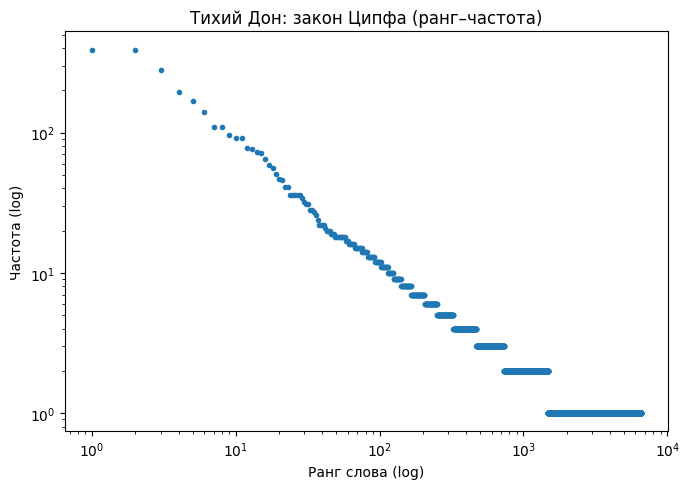

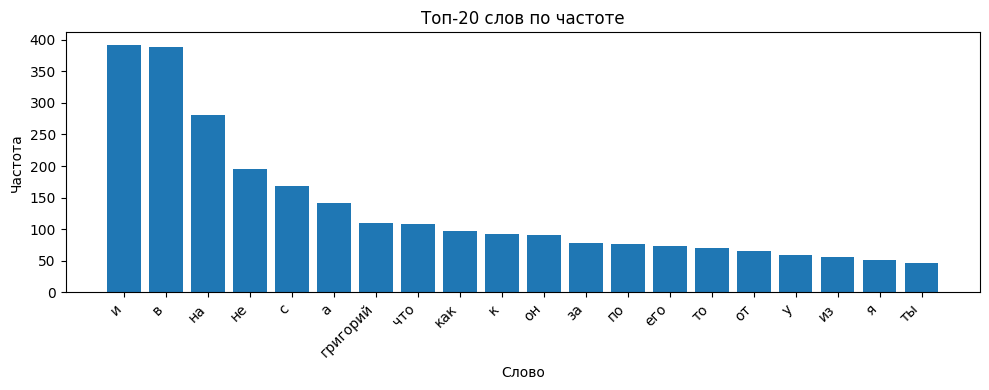

Хвост (c<=3): 6073 типов = 92.8% словаря
Хвост (c<=3): 7346 токенов = 53.8% текста


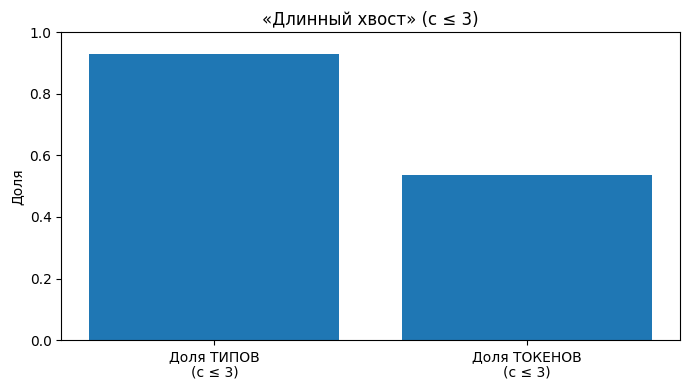

['шуршит',
 'скользят',
 'розовую',
 'отцом',
 'рвался',
 'долгих',
 'порассказать',
 'обстоятельстве',
 'передать',
 'платой']

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Zipf данные
freqs_sorted = np.array(sorted(cnt.values(), reverse=True))
ranks = np.arange(1, len(freqs_sorted) + 1)

# 3.1 Zipf log-log
plt.figure(figsize=(7,5))
plt.loglog(ranks, freqs_sorted, marker=".", linestyle="none")
plt.title("Тихий Дон: закон Ципфа (ранг–частота)")
plt.xlabel("Ранг слова (log)")
plt.ylabel("Частота (log)")
plt.tight_layout()
plt.show()

# 3.2 Топ-20
df_top20 = pd.DataFrame(top20, columns=["word","count"])
plt.figure(figsize=(10,4))
plt.bar(df_top20["word"], df_top20["count"])
plt.title("Топ-20 слов по частоте")
plt.xlabel("Слово")
plt.ylabel("Частота")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3.3 Длинный хвост: <= 3
tail_words = [w for w, c in cnt.items() if c <= 3]
tail_types = len(tail_words)
tail_tokens = sum(cnt[w] for w in tail_words)

print(f"Хвост (c<=3): {tail_types} типов = {tail_types/V_types:.1%} словаря")
print(f"Хвост (c<=3): {tail_tokens} токенов = {tail_tokens/N_tokens:.1%} текста")

plt.figure(figsize=(7,4))
plt.bar(["Доля ТИПОВ\n(c ≤ 3)", "Доля ТОКЕНОВ\n(c ≤ 3)"],
        [tail_types/V_types, tail_tokens/N_tokens])
plt.ylim(0, 1)
plt.title("«Длинный хвост» (c ≤ 3)")
plt.ylabel("Доля")
plt.tight_layout()
plt.show()

# 3.4 (Опционально) 10 случайных hapax (c=1)
hapax = [w for w, c in cnt.items() if c == 1]
rng = np.random.default_rng(0)
sample10 = list(rng.choice(hapax, size=10, replace=False))
sample10


In [ ]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

ru_lemmas_pym = [morph.parse(w)[0].normal_form for w in tokens]
cnt = Counter(stems)
top20 = cnt.most_common(20)
top20[:10]

[('и', 391),
 ('в', 389),
 ('на', 281),
 ('не', 220),
 ('с', 169),
 ('григор', 159),
 ('он', 144),
 ('а', 141),
 ('как', 107),
 ('что', 103)]

In [ ]:
[(ent.text, ent.label_) for ent in doc_ru.ents if ent.label_ == "PER"][:50]

[('Михаил Шолохов', 'PER'),
 ('Том', 'PER'),
 ('Дон', 'PER'),
 ('Дон', 'PER'),
 ('Дону', 'PER'),
 ('Дон', 'PER'),
 ('Дон', 'PER'),
 ('Дона', 'PER'),
 ('Дона', 'PER'),
 ('Шолохова', 'PER'),
 ('Шолохова', 'PER'),
 ('Шолохова', 'PER'),
 ('Л. Толстого', 'PER'),
 ('Гоголя', 'PER'),
 ('Шолохов', 'PER'),
 ('Шолохов', 'PER'),
 ('Шолохову', 'PER'),
 ('Советской', 'PER'),
 ('Шолохов', 'PER'),
 ('М. Горькому', 'PER'),
 ('Верхнего Дона', 'PER'),
 ('Роман', 'PER'),
 ('Шолохова', 'PER'),
 ('Григория Мелехова', 'PER'),
 ('Григория', 'PER'),
 ('Григория', 'PER'),
 ('Григория', 'PER'),
 ('Э. Багрицким', 'PER'),
 ('Григория Мелехова', 'PER'),
 ('Шолохов', 'PER'),
 ('Шолохов', 'PER'),
 ('Ф. Энгельс', 'PER'),
 ('Ибсена', 'PER'),
 ('Дон', 'PER'),
 ('Казачки Дуняша', 'PER'),
 ('Дарья', 'PER'),
 ('Степана Разина', 'PER'),
 ('Емельяна Пугачева', 'PER'),
 ('Кондрата Булавина', 'PER'),
 ('Ленин', 'PER'),
 ('Шолохова', 'PER'),
 ('Бунчука Чикамасов', 'PER'),
 ('Григорий Мелехов', 'PER'),
 ('Верхнего Дона', 'PER')

In [ ]:
sentences = [
    "Она метнула по сторонам испуганным взглядом и прошла, хмурясь и не оглядываясь.",
    "Дуняша козой скакнула к воротам.",
    "Григорий провожал их долгим, неморгающим взглядом.",
    "За левадами палила небо сухая молния, давил землю редкими раскатами гром.",
    "К вечеру собралась гроза. Над хутором стала бурая туча."
]

In [ ]:
for i, sent in enumerate(sentences, 1):
    print("\nspaCy:")
    doc = nlp(sent)
    for token in doc:
        ner = token.ent_type_ if token.ent_type_ else "_"
        print(f"  {token.text:15} POS: {token.pos_:10} DEP: {token.dep_:10} NER: {ner}")
    print("\npymorphy3 (леммы):")
    words = sent.replace(".", "").split()
    for word in words:
        parse = morph.parse(word)[0]
        print(f"  {word:15} -> {parse.normal_form}")


spaCy:
  Она             POS: PRON       DEP: nsubj      NER: _
  метнула         POS: VERB       DEP: ROOT       NER: _
  по              POS: ADP        DEP: case       NER: _
  сторонам        POS: NOUN       DEP: obl        NER: _
  испуганным      POS: VERB       DEP: amod       NER: _
  взглядом        POS: NOUN       DEP: obl        NER: _
  и               POS: CCONJ      DEP: cc         NER: _
  прошла          POS: VERB       DEP: conj       NER: _
  ,               POS: PUNCT      DEP: punct      NER: _
  хмурясь         POS: VERB       DEP: advcl      NER: _
  и               POS: CCONJ      DEP: cc         NER: _
  не              POS: PART       DEP: advmod     NER: _
  оглядываясь     POS: VERB       DEP: conj       NER: _
  .               POS: PUNCT      DEP: punct      NER: _

pymorphy3 (леммы):
  Она             -> она
  метнула         -> метнуть
  по              -> по
  сторонам        -> сторона
  испуганным      -> испуганный
  взглядом        -> взгляд
  и    

## Конец

*Спасибо большое, что Вы проверили мою работу. Если у Вас есть какие-либо вопросы, пожалуйста напишите через телеграм  **[@ngocleltt](https://t.me/ngocleltt)***. Рада и готова ответить!